In [1]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2
import math
import random
import requests
import time
from dataclasses import dataclass
from ratingcalc import binsearch, calcperf

ratinglist = {}
ratinglist_json = requests.get("https://codeforces.com/api/user.ratedList").json()
for user in ratinglist_json["result"]:
    ratinglist[user["handle"]] = user["rating"]

print(f'Total rated users: {len(ratinglist)}')
print(list(ratinglist.items())[:10])


@dataclass
class Contest:
    contestant_ratings: list[int]
    perfs: dict[int, float]

    @classmethod
    def fetch(cls, contest_id: int) -> Contest:
        json = requests.get(f'https://codeforces.com/api/contest.standings?contestId={contest_id}').json()
        cont_ratings = []
        for entry in json['result']['rows']:
            if len(entry['party']['members']) > 1:
                continue
            handle = entry['party']['members'][0]['handle']
            cont_ratings.append(ratinglist.get(handle, 1400))
        perfs = calcperf(cont_ratings)
        return cls(cont_ratings, perfs)


def sim(contest: Contest, r: int, trials: int) -> float:
    """Simulate :trials: trials of a user rated :r:. Return the average rating delta.
    Is quite slow, O(n) where n is number of participants, per trial. There may be a way to sample the distribution faster, but I'm not sure.
    """
    expect_place: float = contest.perfs[r]
    sum_delta = 0.0
    for _ in range(trials):
        placing = 0
        for other_rating in contest.contestant_ratings:
            loss_chance = 1 / (1 + math.exp((r - other_rating) / 173.7178))
            if random.random() < loss_chance:
                placing += 1
        geomean_placing = math.sqrt((placing+1) * (expect_place+1)) - 1  # need to convert to 1-based
        perf_for_delta = binsearch(contest.perfs, geomean_placing)
        delta = (perf_for_delta - r) / 2
        sum_delta += delta
    return sum_delta / trials


Total rated users: 133583
[('Benq', 3792), ('jiangly', 3728), ('EvenImage', 3682), ('zhoukangyang', 3670), ('Kevin114514', 3625), ('Geothermal', 3569), ('maroonrk', 3555), ('strapple', 3515), ('tourist', 3439), ('dXqwq', 3436)]


In [8]:
# Last 10 div1 or div1+2
# CONTESTS = [
#     2239, 2237, 2229, 2223, 2219,
#     2211, 2207, 2201, 2196, 2187,
# ]
# Historic div1 or div1+2 from the end of 2024 (this is when tourist was 4000)
CONTESTS = [
    2053, 2048, 2046, 2034, 2039,
    2029, 2035, 2023, 2018, 2006,
]
RATINGS_TO_CHECK = list(range(2400, 4001, 100))
TRIALS = 1000


# rating -> [list of average deltas for each contest]
results: dict[int, list[float]] = {r: [] for r in RATINGS_TO_CHECK}

start = time.time()
for c in CONTESTS:
    print(f'Contest {c}  [{time.time()-start:.1f}]')
    contest = Contest.fetch(c)
    print(f'  Fetched x{len(contest.contestant_ratings)}  [{time.time()-start:.1f}]')
    for r in RATINGS_TO_CHECK:
        avg_delta = sim(contest, r, TRIALS)
        print(f'  Rating {r}: {avg_delta:.2f}  [{time.time()-start:.1f}]')
        results[r].append(avg_delta)


print(f'\nFinished!  [{time.time()-start:.1f}]\n')
print(results)
print(f'\nAverages:\n')
print({k: sum(v)/len(v) for k, v in results.items()})

Contest 2053  [0.0]
  Fetched x14757  [4.3]
  Rating 2400: 0.35  [6.1]
  Rating 2500: 0.31  [8.0]
  Rating 2600: 0.24  [9.8]
  Rating 2700: 0.38  [11.6]
  Rating 2800: 0.52  [13.5]
  Rating 2900: 0.59  [15.6]
  Rating 3000: 0.66  [17.4]
  Rating 3100: 1.51  [19.2]
  Rating 3200: 1.44  [20.9]
  Rating 3300: 1.16  [22.8]
  Rating 3400: 2.79  [24.5]
  Rating 3500: 2.98  [26.3]
  Rating 3600: 4.58  [28.1]
  Rating 3700: 5.63  [29.9]
  Rating 3800: 8.03  [31.7]
  Rating 3900: 13.32  [33.4]
  Rating 4000: 19.41  [35.2]
Contest 2048  [35.2]
  Fetched x15064  [40.5]
  Rating 2400: 0.48  [42.3]
  Rating 2500: 0.31  [44.1]
  Rating 2600: 0.43  [45.9]
  Rating 2700: 0.41  [47.7]
  Rating 2800: 0.36  [49.5]
  Rating 2900: 0.62  [51.3]
  Rating 3000: 0.56  [53.1]
  Rating 3100: 1.04  [54.8]
  Rating 3200: 0.82  [56.6]
  Rating 3300: 1.60  [58.4]
  Rating 3400: 1.65  [60.2]
  Rating 3500: 2.12  [62.0]
  Rating 3600: 4.14  [63.7]
  Rating 3700: 7.08  [65.5]
  Rating 3800: 10.21  [67.3]
  Rating 3900:

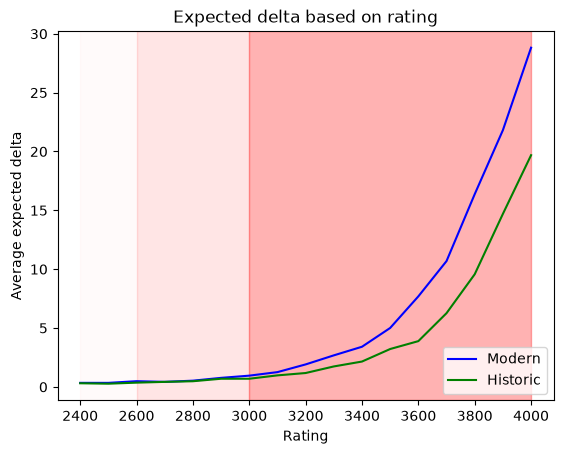

In [22]:
from matplotlib import pyplot as plt


r1 = {2400: 0.34255, 2500: 0.34125, 2600: 0.4843, 2700: 0.42805, 2800: 0.5279499999999999, 2900: 0.7673, 3000: 0.9544, 3100: 1.2544499999999998, 3200: 1.9088, 3300: 2.67815, 3400: 3.40995, 3500: 5.0063, 3600: 7.690299999999999, 3700: 10.6883, 3800: 16.37225, 3900: 21.8109, 4000: 28.81755}
r2 = {2400: 0.3076, 2500: 0.27115, 2600: 0.35995, 2700: 0.426, 2800: 0.4801, 2900: 0.69155, 3000: 0.6923, 3100: 0.978, 3200: 1.1778499999999998, 3300: 1.73655, 3400: 2.15265, 3500: 3.21725, 3600: 3.8872999999999998, 3700: 6.2631, 3800: 9.5688, 3900: 14.697899999999999, 4000: 19.68495}
r1i = list(r1.items())
r2i = list(r2.items())
x1 = [x[0] for x in r1i]
y1 = [x[1] for x in r1i]
x2 = [x[0] for x in r2i]
y2 = [x[1] for x in r2i]


fig, ax = plt.subplots()
ax.axvspan(2400, 2600, color='red', alpha=0.02)
ax.axvspan(2600, 3000, color='red', alpha=0.1)
ax.axvspan(3000, 4000, color='red', alpha=0.3)
plt.plot(x1, y1, label='Modern', color='blue')
plt.plot(x2, y2, label='Historic', color='green')
plt.xlabel('Rating')
plt.ylabel('Average expected delta')
plt.title('Expected delta based on rating')
plt.legend()
plt.savefig('output.png', dpi=800)

In [4]:
def sim(contest: Contest, r_nominal: int, r_real: int, trials: int) -> float:
    """Simulate again, but with user's nominal rating and their real skill being different."""
    expect_place: float = contest.perfs[r_nominal]
    sum_delta = 0.0
    for _ in range(trials):
        placing = 0
        for other_rating in contest.contestant_ratings:
            loss_chance = 1 / (1 + math.exp((r_real - other_rating) / 173.7178))
            if random.random() < loss_chance:
                placing += 1
        geomean_placing = math.sqrt((placing+1) * (expect_place+1)) - 1  # need to convert to 1-based
        perf_for_delta = binsearch(contest.perfs, geomean_placing)
        delta = (perf_for_delta - r_nominal) / 2
        sum_delta += delta
    return sum_delta / trials


print('Fetching...')
CONTESTS = [
    2239, 2237, 2229, 2223, 2219,
    2211, 2207, 2201, 2196, 2187,
]
CONTESTS = [Contest.fetch(c) for c in CONTESTS]
print('Fetching complete!')

Fetching...
Fetching complete!


In [27]:
COMBINATIONS = [
    # Nominal, real
    (3500, 3490), (3500, 3480),
    (3400, 3390), (3400, 3380),
]

for nom, real in COMBINATIONS:
    print(f'Nominal: {nom}, Real: {real}  (would be {nom-real} of inflation)')
    sum1 = 0
    for contest in CONTESTS:
        avg_delta = sim(contest, nom, real, TRIALS)
        sum1 += avg_delta
    print(f'  Average delta: {sum1/len(CONTESTS):.1f}')

Nominal: 3500, Real: 3490  (would be 10 of inflation)
  Average delta: 2.1
Nominal: 3500, Real: 3480  (would be 20 of inflation)
  Average delta: -0.3
Nominal: 3400, Real: 3390  (would be 10 of inflation)
  Average delta: 1.2
Nominal: 3400, Real: 3380  (would be 20 of inflation)
  Average delta: -1.7


In [2]:
from dataclasses import field


@dataclass
class Player:
    real_rating: float
    rating: int
    random_roll: float = field(init=False, default=0.0)

    def draw(self) -> None:
        """Here is the idea.
        Model:
          Suppose a 2000 player has 1 share and a 2400 player has 10 shares. If each share has an equal probability to win,
          then each player would have the correct chance to beat another.
          In the massive leaderboard version, each share will be a random number from 0 to 1. A player with 10 shares takes
          the highest share. In this way, for each pairwise comparison, the rating model should be correct.
        Implementation:
          Simulating exponentially high numbers of shares is not feasible, so we'll instead use the trick that:
            max(x1, x2, ..., xn) is identical in distribution to x^(1/n), for IID uniform random variables in [0, 1].
          Also, this is correct for our purposes for any rational n (and any real n by approximation).
          We will normalize a somewhat sensible value to avoid precision errors. Let 3000 rating = 1 share (less shares / higher exponents save precision).
          The resulting value will be saved under self.random_roll, so you can sort by that key.
        """
        shares = math.exp((self.real_rating - 3000.0) / 173.7178)
        self.random_roll = random.random() ** (1/shares)


def play_one_round(state: list[Player]):
    """Plays one round of the game - rolls for each player, ranks, and updates nominal ratings.
    State is returned in place; it may be shuffled.
    """
    for player in state:
        player.draw()
    state.sort(key=lambda p: p.random_roll, reverse=True)
    cont_ratings = [p.rating for p in state]
    perfs = calcperf(cont_ratings)
    sum_delta = 0.0
    for actual_place, player in enumerate(state):
        expect_place = perfs[player.rating]
        geomean_placing = math.sqrt((actual_place+1) * (expect_place+1)) - 1
        perf_for_delta = binsearch(perfs, geomean_placing)
        delta: float = (perf_for_delta - player.rating) / 2
        player.rating += delta
        sum_delta += delta
    for player in state:
        player.rating -= sum_delta / len(state)  # normalize to adjust for inflation
        player.rating = round(player.rating)

In [3]:
# Example simulation

from ratingcalc import binsearch, calcperf

STARTING_RATING = 3000
players = []
for r in range(2300, 3701, 50):
    players.append(Player(real_rating=r, rating=STARTING_RATING))
for r in range(1, 100+1):
    play_one_round(players)
final_avg_rating = sum([p.rating for p in players]) / len(players)
inflation_adj = final_avg_rating - STARTING_RATING
print(f'Final average rating: {final_avg_rating:.0f}')
for p in sorted(players, key=lambda p: p.real_rating, reverse=True):
    print(f'  {p.rating} (real skill {p.real_rating:.0f})')

Final average rating: 2999
  3972 (real skill 3700)
  3889 (real skill 3650)
  3703 (real skill 3600)
  3842 (real skill 3550)
  3728 (real skill 3500)
  3540 (real skill 3450)
  3466 (real skill 3400)
  3495 (real skill 3350)
  3601 (real skill 3300)
  3305 (real skill 3250)
  3276 (real skill 3200)
  3538 (real skill 3150)
  3274 (real skill 3100)
  3036 (real skill 3050)
  2937 (real skill 3000)
  2817 (real skill 2950)
  2974 (real skill 2900)
  2648 (real skill 2850)
  2624 (real skill 2800)
  2695 (real skill 2750)
  2420 (real skill 2700)
  2345 (real skill 2650)
  2627 (real skill 2600)
  2409 (real skill 2550)
  2287 (real skill 2500)
  2169 (real skill 2450)
  2167 (real skill 2400)
  2213 (real skill 2350)
  1970 (real skill 2300)


In [4]:
TRIALS = 200
# I counted 29 contests in 2025, so let's say 100 is the number of contests a typical competitor competes over up to 5 years.
CONTESTS = 100
# Round each div1 user down to the nearest 50 for some nicer visualization at the end.
USERS = {}
for handle, rating in ratinglist.items():
    simplified_rating = (rating // 50) * 50
    if simplified_rating >= 1900:
        USERS.setdefault(simplified_rating, 0)
        USERS[simplified_rating] += 1
print(USERS)


# data[initial rating][x] = list of final ratings after x contests
data: dict[int, list[list[float]]] = {rating: [[] for x in range(CONTESTS+1)] for rating, ct in USERS.items()}
for rating, ct in USERS.items():
    data[rating][0].append(rating)  # add data point to show starting point
for trial in range(1, TRIALS+1):
    print(f'\rTrial {trial}...', end='', flush=True)
    state = []
    for rating, count in USERS.items():
        for _ in range(count):
            state.append(Player(real_rating=rating, rating=rating))
    for contest in range(1, CONTESTS+1):
        play_one_round(state)
        for player in state:
            data[player.real_rating][contest].append(player.rating)
print()
compressed_data: dict[int, list[float]] = {rating: [sum(v[contest])/len(v[contest]) for contest in range(CONTESTS+1)] for rating, v in data.items()}
print(compressed_data)

{3750: 1, 3700: 1, 3650: 2, 3600: 1, 3550: 2, 3500: 1, 3400: 2, 3350: 4, 3300: 3, 3250: 1, 3200: 2, 3150: 5, 3100: 10, 3050: 23, 3000: 18, 2950: 8, 2900: 20, 2850: 20, 2800: 28, 2750: 39, 2700: 32, 2650: 48, 2600: 86, 2550: 70, 2500: 124, 2450: 171, 2400: 275, 2350: 165, 2300: 212, 2250: 282, 2200: 399, 2150: 643, 2100: 993, 2050: 357, 2000: 531, 1950: 765, 1900: 1165}
Trial 200...
{3750: [3750.0, 3769.735, 3786.085, 3796.91, 3814.32, 3827.795, 3846.46, 3858.67, 3860.63, 3869.93, 3884.295, 3892.155, 3904.74, 3918.6, 3934.11, 3947.97, 3948.66, 3949.09, 3954.0, 3957.28, 3959.61, 3964.375, 3970.165, 3974.525, 3978.87, 3987.22, 3987.28, 3987.525, 3990.215, 3992.56, 3997.32, 4004.11, 4007.875, 4008.345, 4013.92, 4011.99, 4010.84, 4010.63, 4012.12, 4016.925, 4021.05, 4018.325, 4021.49, 4017.285, 4012.68, 4006.945, 4010.725, 4015.755, 4013.39, 4011.145, 4013.52, 4014.815, 4012.055, 4017.045, 4024.77, 4020.04, 4015.35, 4015.855, 4023.47, 4026.05, 4018.71, 4023.535, 4026.465, 4024.89, 4030.545,

/tmp/ipykernel_112710/62414725.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

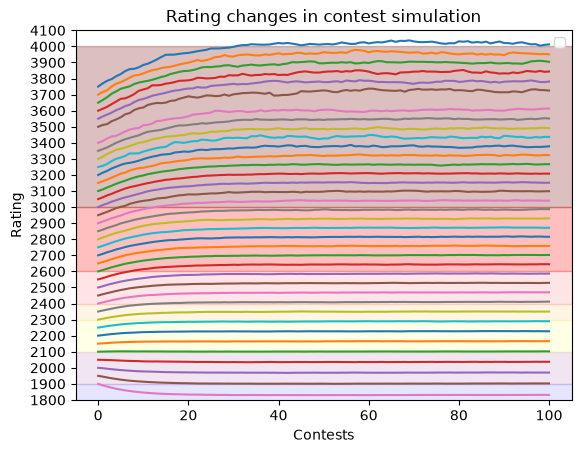

In [7]:
from matplotlib import pyplot as plt
plt.style.use('default')


def graph(low: int, high: int, winlow: int, winhigh: int):
    plt.clf()
    fig, ax = plt.subplots()
    ax.axhspan(1600, 1900, color='blue', alpha=0.1)
    ax.axhspan(1900, 2100, color='purple', alpha=0.1)
    ax.axhspan(2100, 2300, color='yellow', alpha=0.1)
    ax.axhspan(2300, 2400, color='orange', alpha=0.1)
    ax.axhspan(2400, 2600, color='red', alpha=0.1)
    ax.axhspan(2600, 3000, color='red', alpha=0.25)
    ax.axhspan(3000, 4000, color='#770000', alpha=0.25)
    ax.set_ylim(winlow, winhigh)
    ax.set_yticks(range(winlow, winhigh+1, 100))
    #ax.set_yticks([x for x in [1600, 1900, 2100, 2300, 2400, 2600, 3000, 3500, 4000] if winlow <= x <= winhigh])


    for rating, v in compressed_data.items():
        if not (low <= rating <= high):
            continue
        x = list(range(CONTESTS+1))
        y = v
        plt.plot(x, y)
    plt.xlabel('Contests')
    plt.ylabel('Rating')
    plt.title('Rating changes in contest simulation')
    plt.legend()
    plt.savefig(f'output-{low}-{high}.png', dpi=300)


graph(1900, 2400, 1800, 2500)
graph(2400, 3000, 2400, 3200)
graph(3000, 4000, 3000, 4100)
graph(1900, 4000, 1800, 4100)